# Notebook 9 - Multi-Region Earthquake Forecasting

## Objectives

- Load processed earthquake data
- Identify the most active regions
- Forecast earthquake activity for each region
- Rank regions by forecasted activity
- Save results for the dashboard

In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

In [2]:
earthquakes = pd.read_csv(
    "data/processed/earthquakes_processed.csv"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [3]:
earthquakes["Time"] = pd.to_datetime(
    earthquakes["Time"],
    format="mixed",
    utc=True,
    errors="coerce"
)

earthquakes = earthquakes.dropna(subset=["Time"])

In [4]:
earthquakes["Region"] = (
    earthquakes["Location"]
    .fillna("Unknown")
    .str.split(",")
    .str[-1]
    .str.strip()
)

earthquakes[["Location", "Region"]].head()

,Location,Region
0,"69 km E of Yamada, Japan",Japan
1,"173 km NNE of Tobelo, Indonesia",Indonesia
2,"113 km N of Yakutat, Alaska",Alaska
3,"117 km E of Miyako, Japan",Japan
4,"51 km ENE of Chase, Alaska",Alaska


In [5]:
top_regions = (
    earthquakes["Region"]
    .value_counts()
    .head(10)
)

top_regions

Region
Alaska              4583
Russia              3983
Indonesia            878
Japan                811
Philippines          596
CA                   596
Puerto Rico          532
Papua New Guinea     395
Chile                357
Tonga                271
Name: count, dtype: int64

In [6]:
forecast_results = []

for region in top_regions.index:

    region_df = earthquakes[
        earthquakes["Region"] == region
    ].copy()

    region_df["Date"] = region_df["Time"].dt.date

    daily = (
        region_df
        .groupby("Date")
        .size()
        .reset_index(name="Count")
    )

    daily["Date"] = pd.to_datetime(daily["Date"])

    daily = daily.set_index("Date").asfreq("D", fill_value=0)

    if len(daily) < 30:
        continue

    try:

        model = ARIMA(
            daily["Count"],
            order=(1,1,1)
        )

        fit = model.fit()

        prediction = fit.forecast(30)

        forecast_results.append({

            "Region": region,

            "Forecast_30_Days": prediction.sum(),

            "Average_Daily": prediction.mean()

        })

    except:

        continue

In [7]:
forecast_table = pd.DataFrame(
    forecast_results
)

forecast_table = forecast_table.sort_values(
    by="Forecast_30_Days",
    ascending=False
)

forecast_table

,Region,Forecast_30_Days,Average_Daily
0,Alaska,931.299433,31.043314
1,Russia,155.298878,5.176629
2,Indonesia,109.310587,3.643686
5,CA,105.406367,3.513546
3,Japan,101.374594,3.379153
6,Puerto Rico,57.169282,1.905643
4,Philippines,48.235856,1.607862
7,Papua New Guinea,46.341118,1.544704
8,Chile,44.625671,1.487522
9,Tonga,35.867520,1.195584


In [8]:
def risk(score):

    if score > 100:
        return "Very High"

    elif score > 60:
        return "High"

    elif score > 30:
        return "Moderate"

    else:
        return "Low"

forecast_table["Risk"] = forecast_table[
    "Forecast_30_Days"
].apply(risk)

forecast_table

,Region,Forecast_30_Days,Average_Daily,Risk
0,Alaska,931.299433,31.043314,Very High
1,Russia,155.298878,5.176629,Very High
2,Indonesia,109.310587,3.643686,Very High
5,CA,105.406367,3.513546,Very High
3,Japan,101.374594,3.379153,Very High
6,Puerto Rico,57.169282,1.905643,Moderate
4,Philippines,48.235856,1.607862,Moderate
7,Papua New Guinea,46.341118,1.544704,Moderate
8,Chile,44.625671,1.487522,Moderate
9,Tonga,35.867520,1.195584,Moderate


In [9]:
forecast_table.to_csv(
    "outputs/forecasts/multi_region_forecast.csv",
    index=False
)

print("Multi-region forecast saved successfully.")

Multi-region forecast saved successfully.


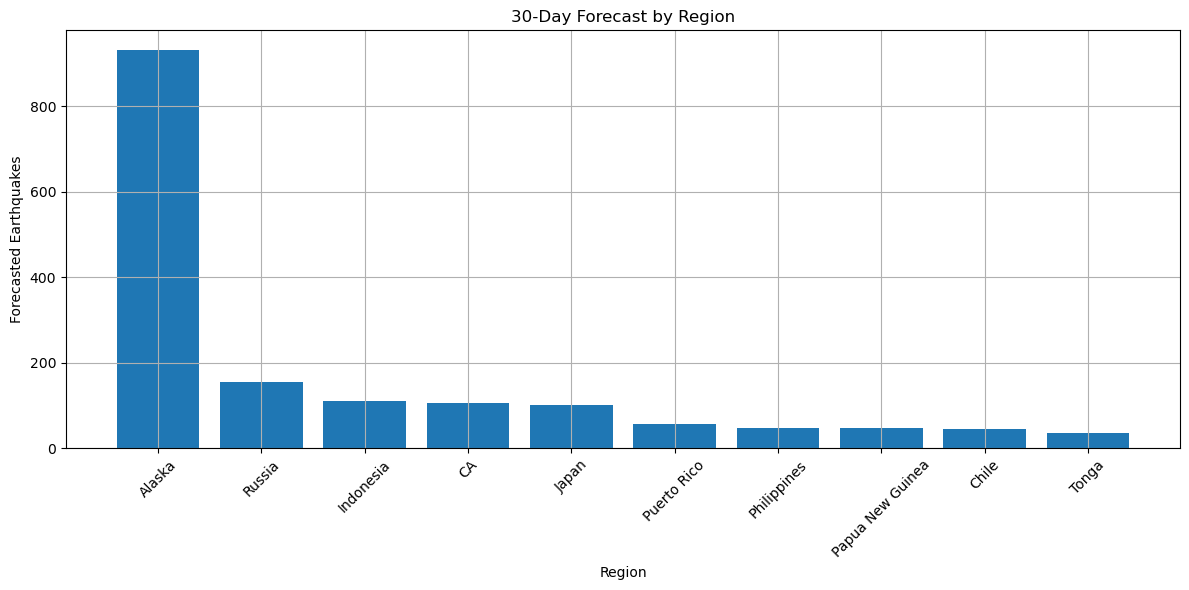

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    forecast_table["Region"],
    forecast_table["Forecast_30_Days"]
)

plt.xticks(rotation=45)

plt.title("30-Day Forecast by Region")

plt.xlabel("Region")

plt.ylabel("Forecasted Earthquakes")

plt.grid(True)

plt.tight_layout()

plt.show()